<a href="https://colab.research.google.com/github/Saurabhrai08/FER/blob/main/fer2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import shutil
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from zipfile import ZipFile
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
data_path = '/content/datasettttt.zip'

with ZipFile(data_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')
    print('Dataset extracted.')

TRAIN_PATH = '/content/datasettttt/train'
TEST_PATH  = '/content/datasettttt/test'

print("\n=== TRAIN ===")
for cls in sorted(os.listdir(TRAIN_PATH)):
    count = len(os.listdir(os.path.join(TRAIN_PATH, cls)))
    print(f"  {cls}: {count} images")

print("\n=== TEST ===")
for cls in sorted(os.listdir(TEST_PATH)):
    count = len(os.listdir(os.path.join(TEST_PATH, cls)))
    print(f"  {cls}: {count} images")


Dataset extracted.

=== TRAIN ===
  angry: 3995 images
  happy: 7215 images
  sad: 4830 images

=== TEST ===
  angry: 958 images
  happy: 1774 images
  sad: 1247 images


In [ ]:
VALID_CLASSES = ['angry', 'happy', 'sad']

for split_path in [TRAIN_PATH, TEST_PATH]:
    for folder in os.listdir(split_path):
        folder_path = os.path.join(split_path, folder)
        if os.path.isdir(folder_path) and folder not in VALID_CLASSES:
            shutil.rmtree(folder_path)
            print(f"Removed junk folder: {folder_path}")

print("Cleanup done.")

Cleanup done.


In [ ]:
IMG_SIZE   = 64
BATCH_SIZE = 32

# Training — with augmentation
train_datagen = ImageDataGenerator(
    rescale            = 1./255,
    rotation_range     = 15,
    horizontal_flip    = True,
    zoom_range         = 0.1,
    width_shift_range  = 0.1,
    height_shift_range = 0.1
)

# Test — only rescale, no augmentation
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = True
)

test_generator = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = False
)

NUM_CLASSES  = train_generator.num_classes
CLASS_LABELS = list(train_generator.class_indices.keys())
print("\nClass mapping:", train_generator.class_indices)

Found 16040 images belonging to 3 classes.
Found 3979 images belonging to 3 classes.

Class mapping: {'angry': 0, 'happy': 1, 'sad': 2}


In [ ]:
class_weights_array = compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(train_generator.classes),
    y            = train_generator.classes
)
class_weights = dict(enumerate(class_weights_array))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.338339591155611), 1: np.float64(0.7410487410487411), 2: np.float64(1.1069703243616287)}


In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')   # 3 classes: angry, happy, sad
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,483 (2.61 MB)

 Trainable params: 684,035 (2.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
model.compile(
    optimizer = 'adam',
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

early_stop = EarlyStopping(
    monitor              = 'val_loss',
    patience             = 5,
    restore_best_weights = True,
    verbose              = 1
)

In [ ]:
history = model.fit(
    train_generator,
    epochs          = 20,
    validation_data = test_generator,
    class_weight    = class_weights,
    callbacks       = [early_stop]
)

Epoch 1/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 47s 77ms/step - accuracy: 0.3982 - loss: 1.1382 - val_accuracy: 0.5381 - val_loss: 0.9980
Epoch 2/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.4667 - loss: 1.0083 - val_accuracy: 0.5625 - val_loss: 0.9423
Epoch 3/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 34s 67ms/step - accuracy: 0.5338 - loss: 0.9553 - val_accuracy: 0.4305 - val_loss: 1.0673
Epoch 4/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 32s 65ms/step - accuracy: 0.5676 - loss: 0.9068 - val_accuracy: 0.4664 - val_loss: 1.2515
Epoch 5/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 33s 66ms/step - accuracy: 0.5959 - loss: 0.8741 - val_accuracy: 0.6474 - val_loss: 0.7742
Epoch 6/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 33s 66ms/step - accuracy: 0.6124 - loss: 0.8455 - val_accuracy: 0.5871 - val_loss: 0.8919
Epoch 7/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.6261 - loss: 0.8302 - val_accuracy: 0.3425 - val_loss: 1.1738
Epoch 8/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.6381 - loss: 0.8226 - 

In [ ]:
model.save("ab2_model.h5")
print("Model saved as ab2_model.h5")

from google.colab import files
files.download('ab2_model.h5')

Model saved as ab2_model.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step


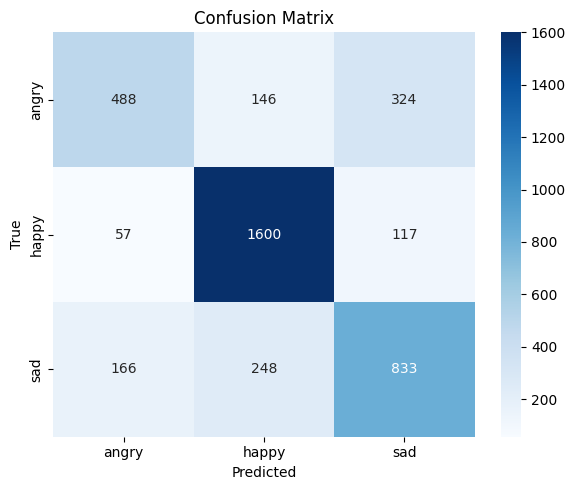

Classification Report:
              precision    recall  f1-score   support

       angry       0.69      0.51      0.58       958
       happy       0.80      0.90      0.85      1774
         sad       0.65      0.67      0.66      1247

    accuracy                           0.73      3979
   macro avg       0.71      0.69      0.70      3979
weighted avg       0.73      0.73      0.73      3979



In [ ]:
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_LABELS,
            yticklabels=CLASS_LABELS)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_LABELS))

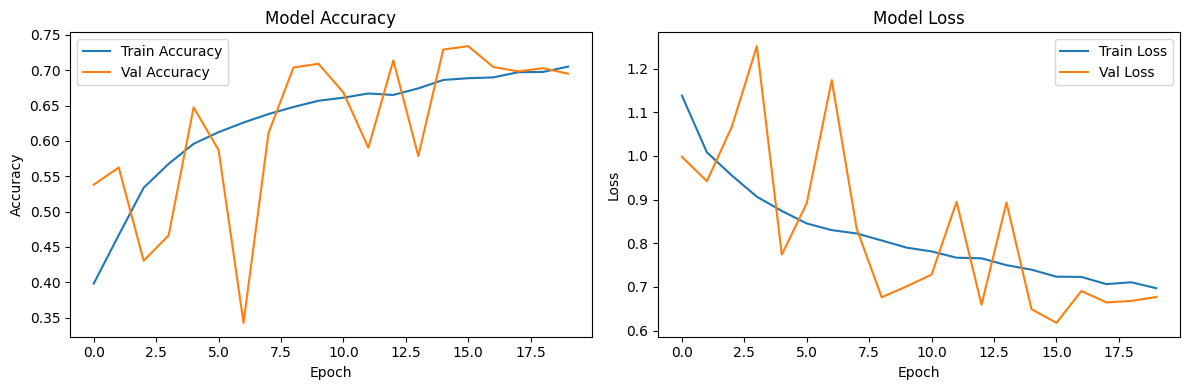

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
model = tf.keras.models.load_model("ab2c_model.h5")

# Must be alphabetical — matches flow_from_directory order
CLASSES  = ['angry', 'happy', 'sad']
IMG_SIZE = 64

image_path = "/content/wert.jpeg"   # ← change this

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
img = img / 255.0
img = np.expand_dims(img, axis=0)

predictions = model.predict(img)
pred_index  = np.argmax(predictions)
pred_class  = CLASSES[pred_index]
confidence  = predictions[0][pred_index] * 100

print("Scores    :", predictions[0].round(4))
print("Probs     :", dict(zip(CLASSES, predictions[0].round(3))))
print(f"Predicted : {pred_class}  ({confidence:.1f}% confidence)")

plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.title(f"Predicted: {pred_class} ({confidence:.1f}%)")
plt.axis('off')
plt.show()





FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'ab2c_model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)